# Table 1

## Cleaning data 

In [95]:
library(ggplot2)
library(bigrquery)
library(tidyverse)
library(lubridate)
library(survival)
library(stats)
library(finalfit)
ProjectId = "yhcr-prd-bradfor-bia-core"

targetdb2 <- 'yhcr-prd-bradfor-bia-core.CB_FDM_DeathCertificates'
targetdb2 <-gsub(' ','',targetdb2)

targetdb3 <- 'yhcr-prd-bradfor-bia-core.CB_2172'
targetdb3 <- gsub(' ','',targetdb3)


download data from connected bradford and create a master table by left joining the care_home_cohort table to the health characterstics

In [3]:
sql1 <- 
paste(
    '
SELECT 
a.*,b.efi2,imd.imd, 
bm.bmi, htn.hypertension, 
bp.systolic_value , 
bp.date_systolic,
pre_bp.systolic_value as pre_admission_systolic_value,
ck.ckd_diagnosis, 
ps.prev_stroke,
dm.dm_diagnosis as diabetes_mellitus, 
af.af_diagnosis, 
chd.chd_diagnosis, 
hf.heart_failure as hf_diagnosis, 
ss.smoking_status, 
p.no_medication
from ',targetdb3,'.care_home_cohort_v1 a 
left join ',targetdb3,'.cb_2172_efi2_value b on a.person_id = b.person_id 
left join ',targetdb3,'.efall_value e on a.person_id = e.person_id
left join ',targetdb3,'.cb_2172_polypharmacy p on a.person_id = p.person_id
left join ',targetdb3,'.temp_cb_2172_efi2_bmi bm on a.person_id = bm.person_id
left join ',targetdb3,'.temp_cb_2172_efi2 efi on a.person_id = efi.person_id
left join ',targetdb3,'.cb_2172_ckd_diagnosis ck on a.person_id = ck.person_id
left join ',targetdb3,'.cb_2172_previous_stroke ps on a.person_id = ps.person_id
left join ',targetdb3,'.cb_2172_ch_imd imd on a.person_id = imd.person_id 
left join ',targetdb3,'.cb_2172_dm_diagnosis dm on a.person_id = dm.person_id 
left join ',targetdb3,'.temp_cb_2172_af_diagnosis af on a.person_id = af.person_id
left join ',targetdb3,'.cb_2172_efi2_hf hf on a.person_id = hf.person_id
left join ',targetdb3,'.cb_2172_smoking_status ss on a.person_id = ss.person_id 
left join ',targetdb3,'.cb_2172_chd_diagnosis chd on a.person_id = chd.person_id 
left join ',targetdb3,'.cb_2172_hypertension_combined htn on a.person_id = htn.person_id
left join ',targetdb3,'.cb_2172_bp_post_admission bp on a.person_id = bp.person_id
left join ',targetdb3,'.cb_2172_bp_pre_admission pre_bp on a.person_id = pre_bp.person_id
;',sep="")

bp_tbl <-bq_project_query(ProjectId,sql1)
bp_data <- bq_table_download(bp_tbl)

## Data Cleaning
First recode the binary variables as factors 

In [4]:
bp_data$hypertension.factor <- as.factor(bp_data$hypertension)

bp_data <- bp_data %>% select(-hypertension)

In [5]:
bp_data$service.factor <- as.factor(bp_data$admission_service)

bp_data <- bp_data %>% select(-admission_service)

In [6]:
bp_data$body_mass_index <- as.numeric(bp_data$bmi)
bp_data <- bp_data %>% select(-bmi)

In [7]:
bp_data$chronic_kidney_disease <- as.factor(bp_data$ckd_diagnosis)
bp_data$chronic_kidney_disease <- fct_na_value_to_level(bp_data$chronic_kidney_disease, "no")
#bp_data <- bp_data %>% select(-ckd_diagnosis)

In [8]:
bp_data$ethnicity.factor <- as.factor(bp_data$Ethnic_Group)
bp_data = bp_data %>% select(-Ethnic_Group)

In [9]:
bp_data$death_date <- as_date(bp_data$dod)
bp_data <- bp_data %>% select(-dod)

In [10]:
bp_data$previous_stroke <- as.factor(bp_data$prev_stroke)

bp_data <- bp_data %>% select(-prev_stroke)

In [11]:
bp_data$gender.factor <- as.factor(bp_data$gender) %>% fct_na_value_to_level("missing")

bp_data <- bp_data %>% select (-gender)

In [12]:
bp_data<- bp_data %>%  mutate(imd.factor = factor(bp_data$imd))

In [13]:
bp_data <-bp_data %>% 
  mutate(imd.factor = imd.factor %>%
           fct_relevel("1","2","3","4","5","6","7","8","9","10","missing")
         )

In [14]:
bp_data$diabetes.factor <- as.factor(bp_data$diabetes_mellitus) %>% fct_na_value_to_level("no")

bp_data <- bp_data %>% select (-diabetes_mellitus)

In [15]:
bp_data$af.factor <- as.factor(bp_data$af_diagnosis) %>% fct_na_value_to_level("no")

bp_data <- bp_data %>% select (-af_diagnosis)

In [16]:
bp_data$hf.factor<- as.factor(bp_data$hf_diagnosis)%>% fct_na_value_to_level("no")

bp_data <- bp_data %>% select (-hf_diagnosis)

In [17]:
bp_data$smoking.factor <- as.factor(bp_data$smoking_status)

bp_data <- bp_data %>%  select(-smoking_status)

code NA values for smoking status as missing factor level 

In [18]:
bp_data$smoking.factor <- fct_na_value_to_level(bp_data$smoking.factor,"missing")
           bp_data$smoking.factor %>% levels()                                 

[1] "current smoker" "ex-smoker"      "non-smoker"     "missing"

In [19]:
bp_data$chd.factor <- as.factor(bp_data$chd_diagnosis) %>% fct_na_value_to_level("no")

bp_data <- bp_data %>% select (-chd_diagnosis)

create factor variable where systolic blood pressure is present or absent 

In [20]:
bp_data <- bp_data %>% mutate(bp_present= case_when(is.na(systolic_value) ~ 'missing',systolic_value > 0 ~ 'yes'))

bp_data$bp_present.factor <- as.factor(bp_data$bp_present)

In [21]:
bp_data <- bp_data %>% mutate(bp_pre_present= case_when(is.na(pre_admission_systolic_value) ~ 'missing',pre_admission_systolic_value > 0 ~ 'yes'))

bp_data$bp_pre_present.factor <- as.factor(bp_data$bp_pre_present)

here we filter the care home cohort for those with a confirmed diagnosis of hypertension at the point of admission. all anaylsis from here on will be restricted to those with a diagnosis of hypertension

In [22]:
bp_data_filtered <- bp_data %>% filter(hypertension.factor == TRUE)

In [23]:
bp_data_filtered %>% group_by(bp_present) %>% summarise(n())

bp_present,n()
<chr>,<int>
missing,431
yes,1594


here I ran some explarotry statistical inference tests to determine whether the missingness of blood pressure values varied significantly between different characteristics 

In [24]:
bp_data_filtered %>% t.test(age_admission ~ bp_present.factor,data=.)


	Welch Two Sample t-test

data:  age_admission by bp_present.factor
t = 0.11478, df = 651.33, p-value = 0.9087
alternative hypothesis: true difference in means between group missing and group yes is not equal to 0
95 percent confidence interval:
 -0.7921108  0.8904669
sample estimates:
mean in group missing     mean in group yes 
             85.44316              85.39398 


In [25]:
#bp_data_filtered %>% t.test(efi2~ bp_present.factor,data=.)

created a new factor variable based on whether blood pressure target was above or below NICE guidelines

In [26]:
bp_data_filtered <- bp_data_filtered %>% 
mutate(bp_target= if_else(systolic_value>=150 & age_admission >= 80| systolic_value>=140 & age_admission <80, "above","below", missing=NULL))

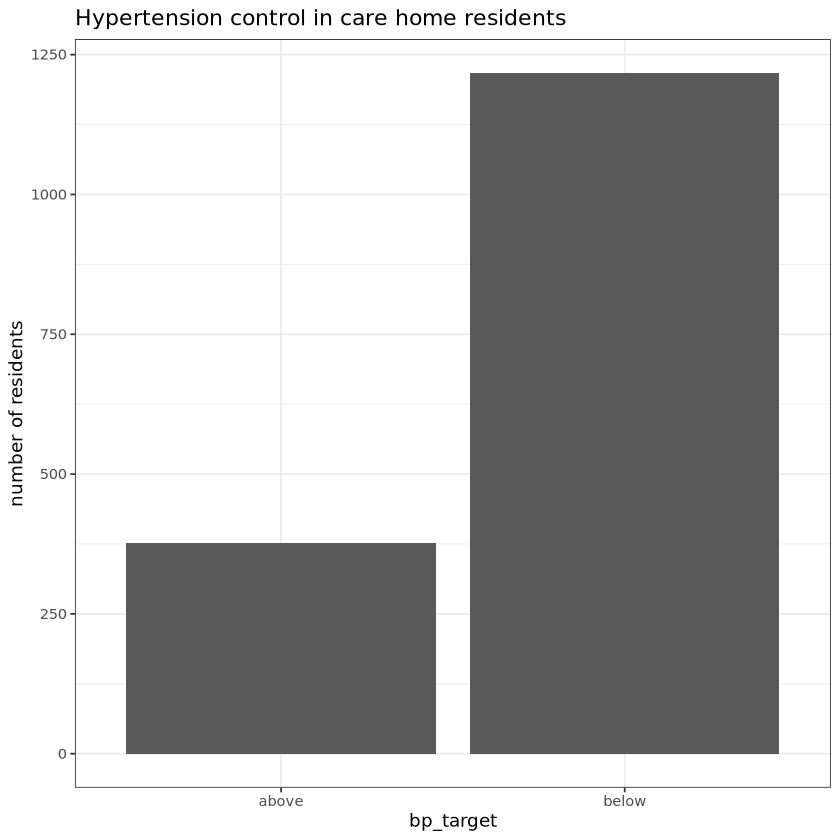

In [27]:
bp_data_filtered %>% filter(systolic_value >0) %>%  ggplot(aes(x= bp_target ))+geom_bar() + theme_bw()  + labs(y= "number of residents", title= "Hypertension control in care home residents")

how many care home residents with hypertension have their blood pressure measured following admission


In [28]:
library(finalfit)
bp_data_filtered %>%  filter(hypertension.factor ==TRUE)%>% 
summary_factorlist(explanatory= "bp_present.factor",
                   ,include_col_totals_percent = TRUE
                   )

No dependent variable(s) provided; defaulting to single-level factor



label,levels,all
<chr>,<chr>,<chr>
bp_present.factor,missing,431 (21.3)
,yes,1594 (78.7)


In [29]:
library(finalfit)
bp_data_filtered %>%  filter(hypertension.factor ==TRUE)%>% 
summary_factorlist(explanatory= "bp_pre_present.factor",
                   ,include_col_totals_percent = TRUE
                   )

No dependent variable(s) provided; defaulting to single-level factor



label,levels,all
<chr>,<chr>,<chr>
bp_pre_present.factor,missing,182 (9.0)
,yes,1843 (91.0)


### demographics table

calculate median life exeptancy and create a new variable with mortality in months 

Warning message:
“Removed 119 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_bar()`).”
Warning message:
“Removed 119 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_bar()`).”


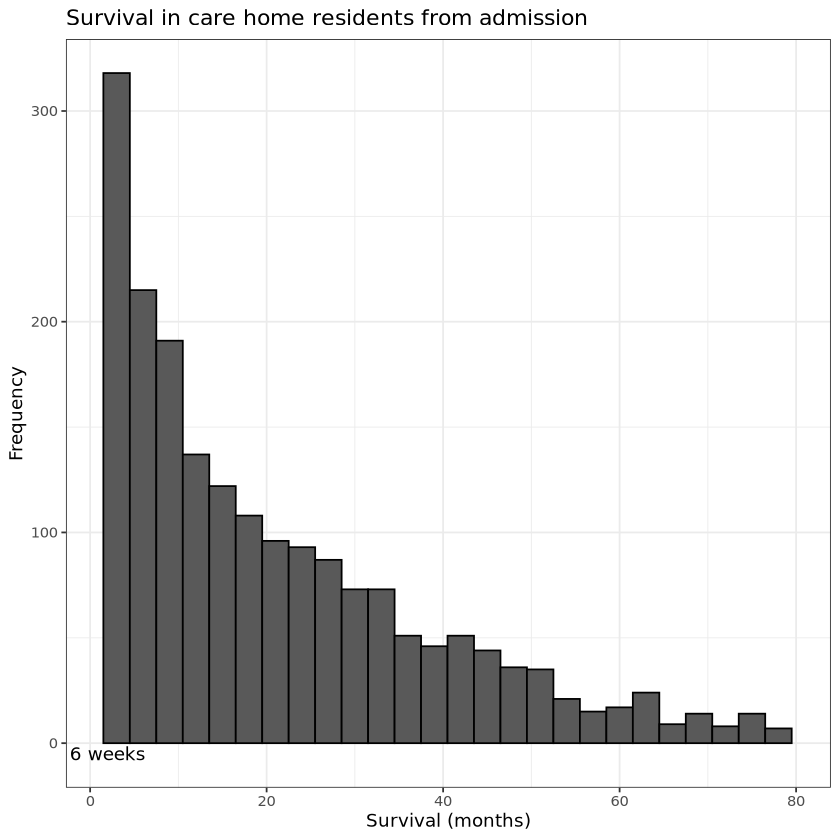

In [83]:
bp_data_filtered %>% ggplot(aes(x=mortality_month))+geom_histogram(binwidth = 3,col="black")+
#geom_vline(xintercept = median(bp_data_filtered$mortality_month,na.rm = TRUE), 
#color = "red", linetype = "dashed", linewidth = 1) +
labs(title = "Survival in care home residents from admission",x="Survival (months)",y="Frequency")+
theme_bw()+xlim(1.2,80) + 
annotate("text", x = 2, y = -5, label = "6 weeks")

ggsave("life_exp_hist.png", width = 10, height = 10)

In [32]:

#recategorised the ethnicities so counts were above 10 
bp_data_filtered %>% mutate(ethnicity.factor = fct_collapse(ethnicity.factor, "mixed/other ethnic groups" = c(
"Mixed/Multiple ethnic groups",
"Other ethnic group"))) %>%  mutate(
        age_admission = ff_label(age_admission, "Age at admission"),
      service.factor = ff_label(service.factor,"Service Type"),
      ethnicity.factor = ff_label(ethnicity.factor,"Ethnicity"),
      admission_length = ff_label(admission_length,"Admission length"),
      gender.factor = ff_label(gender.factor,"gender"),
      mortality = ff_label(mortality,"Lifespan"),
      imd= ff_label(imd.factor,"Index of multiple deprivation(deciles)")
    ) %>% summary_factorlist(dependent= NULL, explanatory = c("age_admission","service.factor","gender.factor","imd","ethnicity.factor","mortality") ) 

No dependent variable(s) provided; defaulting to single-level factor



label,levels,all
<chr>,<chr>,<chr>
Age at admission,Mean (SD),85.4 (7.6)
Service Type,Nursing,1139 (56.2)
,Residential,886 (43.8)
gender,F,1326 (65.5)
,M,699 (34.5)
,missing,0 (0.0)
Index of multiple deprivation(deciles),1,408 (20.2)
,2,183 (9.0)
,3,218 (10.8)


In [33]:
bp_data_filtered$mortality_month %>% median(na.rm = TRUE)

[1] 16

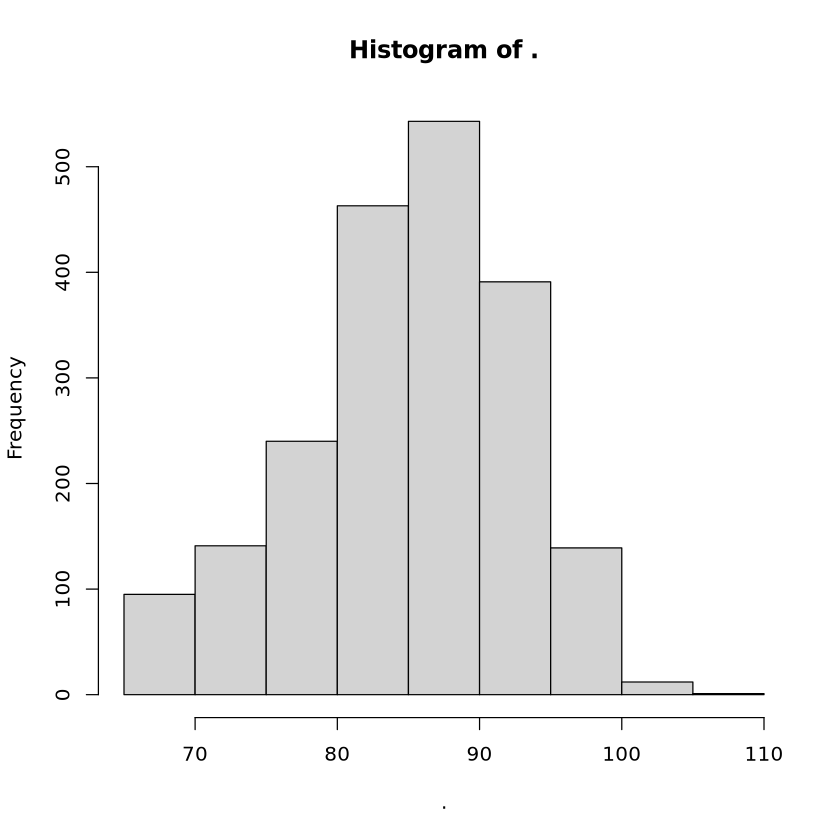

In [34]:
#checking that age on admission is normally distributed
as.numeric(bp_data_filtered$age_admission)%>% hist()

In [35]:
#set BMI values to missing if outside range of 15 and 60. 

bp_data_filtered$body_mass_index <- as.numeric(bp_data_filtered$body_mass_index)

bp_data_filtered$body_mass_index <- ifelse(bp_data_filtered$body_mass_index < 10 | 
bp_data_filtered$body_mass_index > 70, NA, bp_data_filtered$body_mass_index)

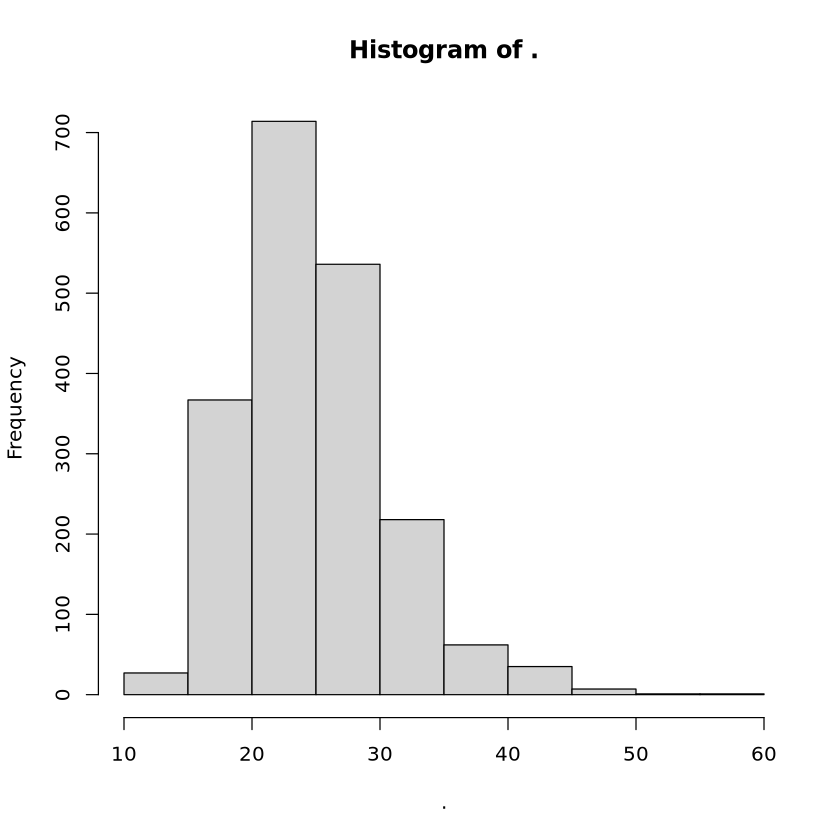

In [36]:
#check that BMI is normally distributed
bp_data_filtered$body_mass_index %>% hist()

## Cardiovascular Risk Factors 

In [37]:
bp_data_filtered %>% 
 mutate(body_mass_index = ff_label(body_mass_index,"Body mass index"),
      af.factor = ff_label(af.factor,"Atrial Fibrillation"),
     chronic_kidney_disease = ff_label(chronic_kidney_disease,"Chronic Kidney Disease"),
      hf.factor	 = ff_label(hf.factor,"Heart Failure"),
      chd.factor = ff_label(chd.factor,"Coronary Heart Disease"),
      diabetes.factor= ff_label(diabetes.factor,"Diabetes Mellitus"),
        smoking.factor= ff_label(smoking.factor, "Smoking Status"),
        previous_stroke = ff_label(previous_stroke,"Previous stroke")) %>% 
summary_factorlist(dependent= NULL, explanatory = c("body_mass_index","af.factor","chronic_kidney_disease","hf.factor","chd.factor","diabetes.factor","smoking.factor","previous_stroke"),na_include =TRUE,na_to_p =TRUE )

No dependent variable(s) provided; defaulting to single-level factor

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chronic_kidney_disease = (function (f, na_level = "(Missing)")
  ...`.
Caused by warning:
! `fct_explicit_na()` was deprecated in forcats 1.0.0.
ℹ Please use `fct_na_value_to_level()` instead.
ℹ The deprecated feature was likely used in the dplyr package.
  Please report the issue at <https://github.com/tidyverse/dplyr/issues>.”


label,levels,all
<chr>,<chr>,<chr>
Body mass index,Mean (SD),24.9 (5.7)
Atrial Fibrillation,no,1566 (77.3)
,yes,459 (22.7)
Chronic Kidney Disease,yes,715 (35.3)
,no,1310 (64.7)
Heart Failure,yes,331 (16.3)
,no,1694 (83.7)
Coronary Heart Disease,yes,505 (24.9)
,no,1520 (75.1)


## Electronic frailty index 2

In [38]:
bp_data_filtered <- bp_data_filtered %>% 
  mutate(
    efi2.factor = 
      efi2 %>%
      cut(breaks = c(0,0.12,0.24,0.36,0.999), include.lowest= TRUE) %>% 
      fct_recode(
        "fit"      =  "[0,0.12]",
        "mild frailty" = "(0.12,0.24]",
        "moderate frailty" = "(0.24,0.36]",
        "severe frailty"  = "(0.36,0.999]"
      ) %>% 
      ff_label("Efi2 category"))



In [39]:
bp_data_filtered %>% summary_factorlist(dependent = ,explanatory=c("efi2.factor"),na_include=TRUE,total_col =TRUE)

No dependent variable(s) provided; defaulting to single-level factor



label,levels,all,Total
<chr>,<chr>,<chr>,<chr>
Efi2 category,fit,98 (4.8),98 (4.8)
,mild frailty,485 (24.0),485 (24.0)
,moderate frailty,856 (42.3),856 (42.3)
,severe frailty,586 (28.9),586 (28.9)


In [40]:
#how many with a valid death date for analysis
nrow(bp_data_filtered[!is.na(bp_data_filtered$mortality),])

[1] 1922

## Hypertension Prevalence


In [41]:
bp_data %>% summary_factorlist(dependent=NULL, explanatory = c("hypertension.factor"),na_to_prop=TRUE)

No dependent variable(s) provided; defaulting to single-level factor



label,levels,all
<chr>,<chr>,<chr>
hypertension.factor,FALSE,749 (27.0)
,TRUE,2025 (73.0)


In [42]:
n <- bp_data %>% nrow()

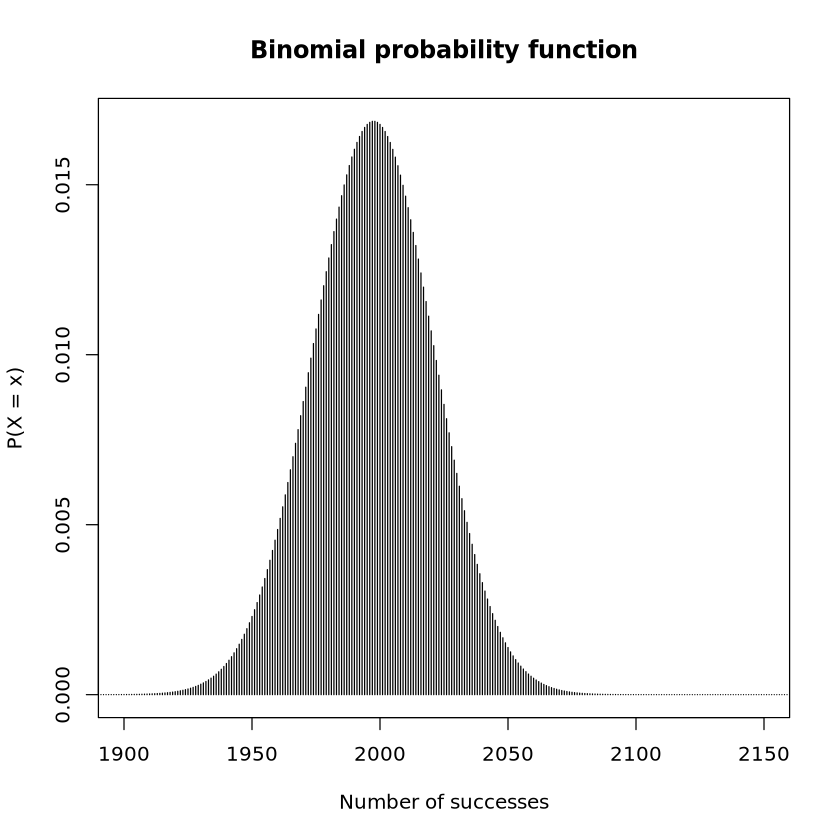

In [43]:
x <- 1:n
plot(dbinom(x, size = n, prob = 0.72), type = "h",
     main = "Binomial probability function",
     ylab = "P(X = x)", xlab = "Number of successes",xlim=c(1900,2150))

In [44]:
 binom.test(2025,(749+2025), conf.level = 0.95)


	Exact binomial test

data:  2025 and (749 + 2025)
number of successes = 2025, number of trials = 2774, p-value < 2.2e-16
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.7130544 0.7464446
sample estimates:
probability of success 
             0.7299928 


In [45]:
bp_data$bp_reading_factor <- as.factor(bp_data$bp_present)

# Antihypertensive medicaiton 

i filtered out those with a mortality less than 6 months for the anaylsis below 

In [46]:
sql_med<- paste('SELECT * from `CB_2172.cb_2172_antihypertensive_long_format` where person_id in (select person_id from ',targetdb3,'.care_home_cohort_v1 ) ;',sep="")

tbl_med <-bq_project_query(ProjectId,sql_med)

tbl_med <- bq_table_download(tbl_med)

tbl_med_f <- tbl_med

In [47]:
#switch time_status and medication binary variables to factor variables 
tbl_med_f$time_status.factor <- as.factor(tbl_med_f$time_status)

tbl_med_f <- tbl_med_f %>% select(-time_status)

In [48]:
tbl_med_ef <- tbl_med_f %>% filter(!( time_status.factor == "post_admission" & early_death == "true"))


### this section will produce a table of the type of antihypertensives prescribed and how this changes during admission in those with hypertension

In [49]:
tbl_med_class <-tbl_med_ef

In [50]:
tbl_med_class$beta_blocker.factor <- as.factor(tbl_med_class$beta_blocker)

tbl_med <- tbl_med_class %>% select(-beta_blocker)

In [51]:
tbl_med_class$calcium_channel_blocker.factor <- as.factor(tbl_med_class$calcium_channel_blocker)

tbl_med_class <- tbl_med_class %>% select(-calcium_channel_blocker)

In [52]:
tbl_med_class$thiazide.factor <- as.factor(tbl_med_class$thiazide_type_diuretic)

tbl_med_class <- tbl_med_class %>% select(-thiazide_type_diuretic)

In [53]:
tbl_med_class$angiotensin_receptor_blocker.factor <- as.factor(tbl_med_class$angiotensin_receptor_blocker)

tbl_med_class <- tbl_med_class %>% select(-angiotensin_receptor_blocker)

In [54]:
tbl_med_class$ace_inhibitor.factor <- as.factor(tbl_med_class$ace_inhibitor)

tbl_med_class <- tbl_med_class %>% select(-ace_inhibitor)

In [55]:
tbl_med_class$alpha_blocker.factor <- as.factor(tbl_med_class$alpha_blocker)

tbl_med_class <- tbl_med_class %>% select(-alpha_blocker)


In [56]:
tbl_med_class$early_death.factor <- as.factor(tbl_med_class$early_death)

tbl_med_class <- tbl_med_class %>% select(-early_death)

In [57]:
tbl_med$time_status.factor %>% levels()

[1] "admission"      "post_admission" "pre_admission"

In [58]:
 tbl_med_class <- tbl_med_class %>% 
  mutate(time_status.factor = time_status.factor %>% 
           fct_relevel("pre_admission"))

tbl_med_class$time_status.factor %>% levels()

[1] "pre_admission"  "admission"      "post_admission"

In [59]:
tbl_med_class %>%
mutate(calcium_channel_blocker.factor = ff_label(calcium_channel_blocker.factor,"Calcium Channel Blocker"),
      ace_inhibitor.factor = ff_label(ace_inhibitor.factor,"Ace Inhibitor"),
     angiotensin_receptor_blocker.factor = ff_label(angiotensin_receptor_blocker.factor,"Angiotensin Receptor Blocker"),
      alpha_blocker.factor = ff_label(alpha_blocker.factor,"Alpha Blocker"),
      thiazide.factor = ff_label(thiazide.factor,"Thiazide Diuretic"),
      ) %>% summary_factorlist(dependent   ="time_status.factor" , 
                     explanatory = c("calcium_channel_blocker.factor", "ace_inhibitor.factor","beta_blocker.factor","angiotensin_receptor_blocker.factor","alpha_blocker.factor","thiazide.factor"),na_include
 = FALSE,add_dependent_label=FALSE) 


label,levels,pre_admission,admission,post_admission
<chr>,<chr>,<chr>,<chr>,<chr>
Calcium Channel Blocker,false,1801 (88.9),1858 (91.8),1481 (93.1)
,true,224 (11.1),167 (8.2),110 (6.9)
Ace Inhibitor,false,1690 (83.5),1834 (90.6),1455 (91.5)
,true,335 (16.5),191 (9.4),136 (8.5)
beta_blocker.factor,false,1598 (78.9),1634 (80.7),1290 (81.1)
,true,427 (21.1),391 (19.3),301 (18.9)
Angiotensin Receptor Blocker,false,1876 (92.6),1939 (95.8),1535 (96.5)
,true,149 (7.4),86 (4.2),56 (3.5)
Alpha Blocker,false,1972 (97.4),1998 (98.7),1575 (99.0)


### this next section will etermine the number of antihypertnesives prescribed for each inidiudal and how this changes ove rthe course of an admission 

In [60]:
tbl_antihypertensive_class <- tbl_med_class %>%  filter(time_status.factor == 'admission')

In [61]:
#convert medication data into long format

In [62]:
tbl_med_long <- tbl_med_ef %>% pivot_longer(beta_blocker:alpha_blocker,names_to = "antihypertensive",values_to= "prescribed")

tbl_med_long_bb <- tbl_med_ef %>%  pivot_longer(beta_blocker:alpha_blocker,names_to = "antihypertensive",values_to= "prescribed") %>% filter(!(antihypertensive == "beta_blocker"))

In [63]:
#recode antihypertenisve classess as factor vectors

In [64]:
tbl_med_long$antihypertensive.factor <- as.factor(tbl_med_long$antihypertensive)
tbl_med_long<- tbl_med_long %>% select(-antihypertensive)

In [65]:
tbl_med_long_bb$antihypertensive.factor <- as.factor(tbl_med_long_bb$antihypertensive)
tbl_med_long_bb<- tbl_med_long_bb %>% select(-antihypertensive)

In [66]:
tbl_med_long_bb$prescribed.factor <- as.factor(tbl_med_long_bb$prescribed)
tbl_med_long_bb<- tbl_med_long_bb %>% select(-prescribed)

In [67]:
#this was attempt at trying to do the group_by function in R< but didn't work so i just sent it back to bigquery and did it there because i know how to do it with SQL
#tbl_med_long_filtered <- tbl_med_long  %>%   group_by(person_id, tbl_med_long$time_status.factor)%>% summarise(antihypertensive.factor)

In [68]:
names(tbl_med_long)[names(tbl_med_long) == "antihypertensive.factor"] <- "antihypertensive_type"
names(tbl_med_long)[names(tbl_med_long) == "time_status.factor"] <- "time_factor"

In [69]:
names(tbl_med_long_bb)[names(tbl_med_long_bb) == "antihypertensive.factor"] <- "antihypertensive_type"
names(tbl_med_long_bb)[names(tbl_med_long_bb) == "time_status.factor"] <- "time_factor"

## this bit is to generate a graph  showing  changes in prescribing by medication class minus beta-blockers


In [70]:
tbl_med_long_bb_grouped <- tbl_med_long_bb %>% group_by(antihypertensive_type,time_factor,prescribed.factor)%>% summarise(sub_total = n())

`summarise()` has grouped output by 'antihypertensive_type', 'time_factor'. You
can override using the `.groups` argument.


In [71]:
tbl_med_long_bb_grouped_percentage <- tbl_med_long_bb_grouped %>% group_by(time_factor,antihypertensive_type)%>% mutate(total = sum(sub_total))%>% mutate(percentage_prescribed = (sub_total/total)*100) %>%   mutate(time_factor = time_factor %>% 
           fct_relevel("pre_admission"))


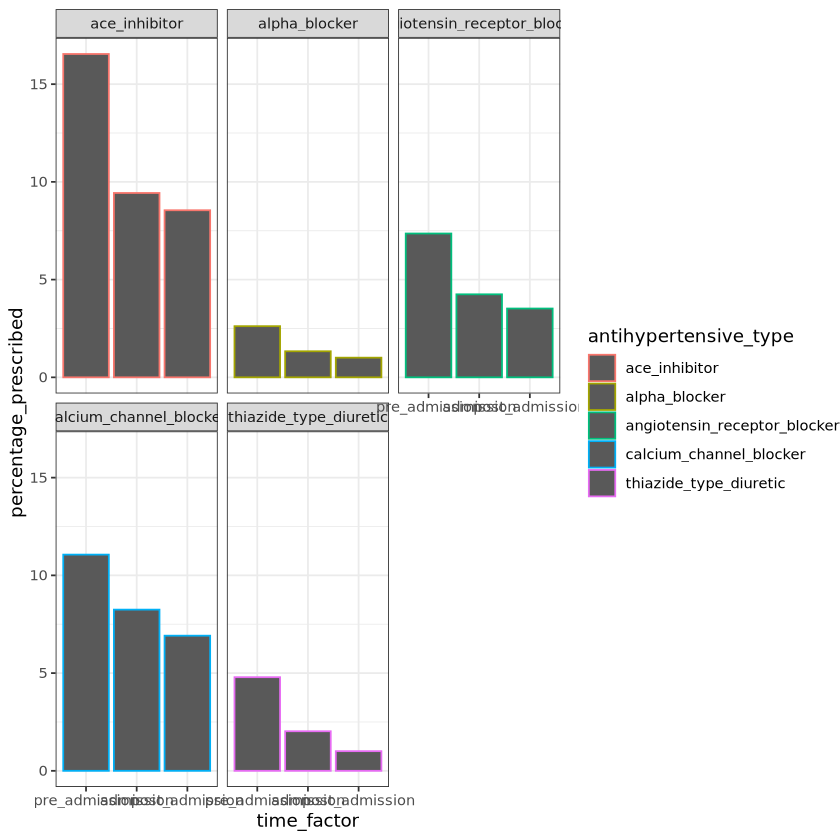

In [72]:
tbl_med_long_bb_grouped_percentage %>% filter(prescribed.factor == "true") %>% ggplot(aes(x=time_factor,y=percentage_prescribed,colour=antihypertensive_type))+geom_col()+theme_bw()+facet_wrap("antihypertensive_type")

In [73]:
mybq = bq_table(project='yhcr-prd-bradfor-bia-core', dataset='CB_2172', table='tbl_med_long_filtered')
bq_table_upload(x=mybq, values= tbl_med_long, create_disposition='CREATE_IF_NEEDED', 
             write_disposition='WRITE_TRUNCATE')

In [74]:
sql4<- paste(
    'SELECT person_id, time_factor, avg(no_antihypertensive) as number_antihypertensive 
FROM `yhcr-prd-bradfor-bia-core.CB_2172.tbl_med_long_filtered` 
group by person_id, time_factor 
order by person_id, time_factor;'
             ,sep="")

tbl_antihtn <-bq_project_query(ProjectId,sql4)

tbl_antihtn <- bq_table_download(tbl_antihtn)



In [75]:
sql5<- paste(
    'SELECT person_id, time_factor, avg(no_antihypertensive) as number_antihypertensive 
FROM `yhcr-prd-bradfor-bia-core.CB_2172.tbl_med_long_filtered_minus_bb` 
group by person_id, time_factor 
order by person_id, time_factor;'
             ,sep="")

tbl_antihtn_1 <-bq_project_query(ProjectId,sql5)

tbl_antihtn_minus_bb <- bq_table_download(tbl_antihtn_1)



In [76]:
 tbl_antihtn$number_antihypertensive.factor <- as.factor(tbl_antihtn$number_antihypertensive)%>% fct_collapse("4+"=c(4,5))
 tbl_antihtn$time.factor <- as.factor(tbl_antihtn$time_factor)

In [77]:
 tbl_antihtn <- tbl_antihtn %>% 
  mutate(time.factor = time.factor %>% 
           fct_relevel("pre_admission"))


In [78]:
deprescribing_tibble <- tbl_antihtn %>% 
summary_factorlist(dependent   ="time.factor", 
                     explanatory = c("number_antihypertensive.factor"),add_col_totals =TRUE)

deprescribing_tibble

label,levels,pre_admission,admission,post_admission
<chr>,<chr>,<chr>,<chr>,<chr>
Total N (%),,2025 (35.9),2025 (35.9),1591 (28.2)
number_antihypertensive.factor,0,1123 (55.5),1338 (66.1),1082 (68.0)
,1,587 (29.0),501 (24.7),403 (25.3)
,2,251 (12.4),159 (7.9),87 (5.5)
,3,61 (3.0),24 (1.2),18 (1.1)
,4+,3 (0.1),3 (0.1),1 (0.1)


In [79]:
tbl_antihtn_group_1 <- tbl_antihtn %>% group_by(number_antihypertensive.factor,time.factor) %>% mutate(total_time_class =sum(n()))

tbl_antihtn_group_2 <- tbl_antihtn_group_1 %>% group_by(time.factor) %>% mutate(total_time = sum(n())) %>% mutate(percentage_class_time = (total_time_class/total_time * 100))

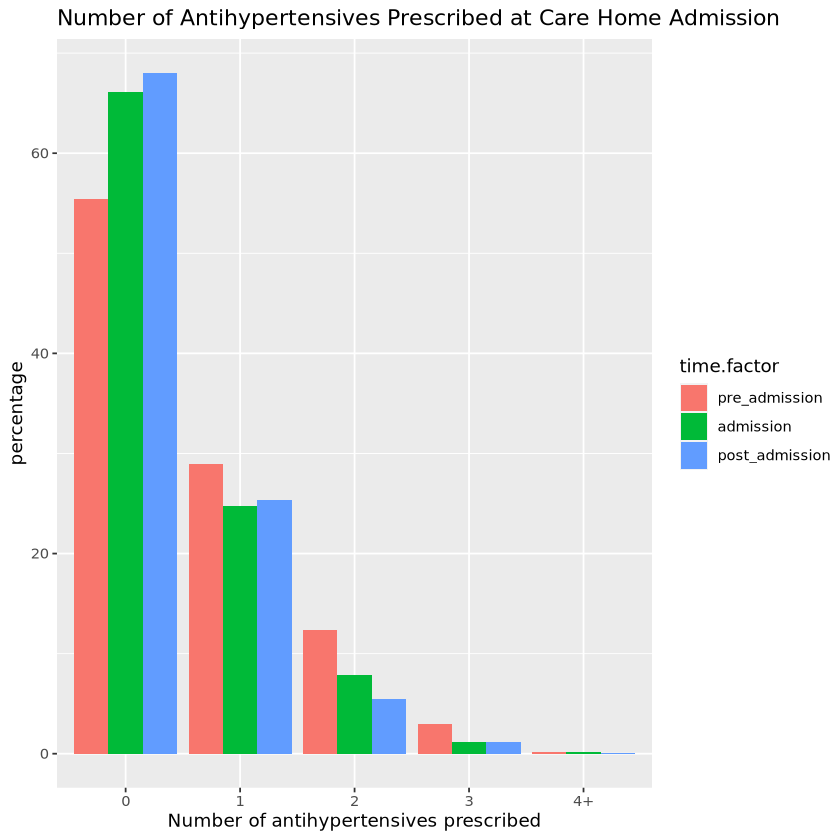

In [80]:
tbl_antihtn_group_2 %>% ggplot( aes(fill=time.factor, y=percentage_class_time, x=number_antihypertensive.factor)) + 
    geom_bar(position="dodge", stat="identity")+  ggtitle("Number of Antihypertensives Prescribed at Care Home Admission")+ 
    xlab("Number of antihypertensives prescribed")+ylab("percentage")

In [81]:
master_tibble %>% ggplot(aes(x=number_antihypertensive.factor,fill=bp_target))+geom_bar(position="fill")+labs(x="number of antihypertensives",y="proportion with bp present")

ERROR: Error: object 'master_tibble' not found


## we then repeat the above analysis but minus beta blockers

In [ ]:
 tbl_antihtn_minus_bb$number_antihypertensive.factor <- as.factor(tbl_antihtn_minus_bb$number_antihypertensive)%>% fct_collapse("3+"=c(3,4,5))
 tbl_antihtn_minus_bb$time.factor <- as.factor(tbl_antihtn_minus_bb$time_factor)

In [ ]:
 tbl_antihtn_minus_bb <- tbl_antihtn_minus_bb %>% 
  mutate(time.factor = time.factor %>% 
           fct_relevel("pre_admission"))


In [ ]:
deprescribing_tibble <- tbl_antihtn_minus_bb %>% 
summary_factorlist(dependent   ="time.factor", 
                     explanatory = c("number_antihypertensive.factor"),add_col_totals =TRUE)

deprescribing_tibble

In [ ]:
tbl_antihtn_minus_bb_group_1 <- tbl_antihtn_minus_bb %>% group_by(number_antihypertensive.factor,time.factor) %>% mutate(total_time_class =sum(n()))

tbl_antihtn_minus_bb_group_2 <- tbl_antihtn_minus_bb_group_1 %>% group_by(time.factor) %>% mutate(total_time = sum(n())) %>% mutate(percentage_class_time = (total_time_class/total_time * 100))

In [ ]:
tbl_antihtn_minus_bb_group_2 %>% ggplot( aes(fill=time.factor, y=percentage_class_time, x=number_antihypertensive.factor)) + 
    geom_bar(position="dodge", stat="identity")+  ggtitle("Number of Antihypertensives Prescribed at Care Home Admission")+ 
    xlab("Number of antihypertensives prescribed")+ylab("percentage")+scale_fill_discrete("Time Point",labels=c('Before Admission', 'Admission','After Admission'))

## Blood pressure measurements

In [ ]:
# join the number of medications at admission to the master cohort dataframe in order to calculate number of people with BP measurements after admission by number of medication 

In [101]:
no_medication <- tbl_antihtn_minus_bb %>% filter(time_factor == 'admission')

In [102]:
master_tibble<-bp_data_filtered %>% inner_join(no_medication, by="person_id")


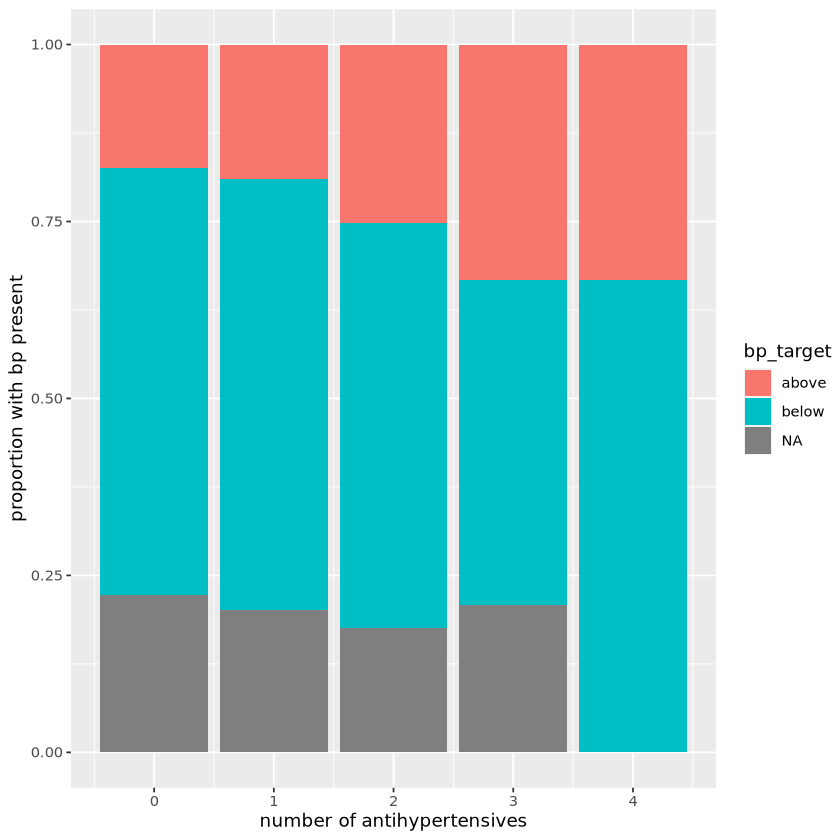

In [103]:
master_tibble %>% ggplot(aes(x=number_antihypertensive,fill=bp_target))+geom_bar(position="fill")+labs(x="number of antihypertensives",y="proportion with bp present")

In [104]:
master_tibble %>%  summary_factorlist(explanatory   ="bp_target")

No dependent variable(s) provided; defaulting to single-level factor



label,levels,all
<chr>,<chr>,<chr>
bp_target,above,377 (23.7)
,below,1217 (76.3)


In [105]:
bp_data$observation_period_end_date %>% max()

[1] "2023-11-13"

## Blood Pressure difference analysis

exploratory analysis to determine whether there is a significant change in systolic blood pressure values before and after admission. 
complete case analysis, only those on antihypertensive medication 
independent t-test to determine differnce in blood pressure before and after admission 

In [106]:
bp_data_filtered$systolic_value <- as.numeric(bp_data_filtered$systolic_value) 

In [107]:
bp_data_filtered$pre_admission_systolic_value <- as.numeric(bp_data_filtered$pre_admission_systolic_value) 

filter for those individuals who had blood pressure recorded before and after admission

In [108]:
bp_present <- bp_data_filtered %>%  filter(bp_pre_present == 'yes' & bp_present == 'yes') 

In [109]:
bp_present <- bp_present %>% mutate(systolic_difference = (systolic_value - pre_admission_systolic_value))

In [110]:
bp_present <- bp_present %>% mutate(systolic_death_days =as.numeric(difftime(death_date,date_systolic, units = "days")))

create new variable which determines whether the systolic variable was recorded within 30 days of death

In [111]:
bp_present <- bp_present %>% mutate(eol_measurement = 
    case_when(
      systolic_death_days < 60 ~ "true",
       systolic_death_days == 60 ~ "true",
      systolic_death_days > 60 ~ "false"))

 identify those prescribed antihypertensives on admission to care home and filter for them 

In [112]:
tbl_med_long_filtered <- tbl_med_long %>% filter(time_factor == 'admission' & no_antihypertensive >= 1) %>% distinct( person_id, .keep_all = FALSE)

In [113]:
bp_present_filtered <- bp_present[bp_present$person_id %in% tbl_med_long_filtered$person_id, ]

In [114]:
bp_present_filtered <- bp_present_filtered  %>% 
select(-bp_pre_present, -bp_present, -first_episodestartdate,-birth_date,-mortality_month,-bp_present.factor,-bp_pre_present.factor, -efi2,-imd, -finalisedPSR,- gender_source_value, -date_of_admission)

ERROR: [1m[33mError[39m in `select()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `finalisedPSR` doesn't exist.


run paired t test analysis

In [ ]:
t.test(bp_present_filtered$pre_admission_systolic_value, bp_present_filtered$systolic_value, paired = TRUE)

run a sensitivity analyis to eliminate blood pressure values performed in the last year of life

run paired t test analysis

In [ ]:
bp_present_filtered_2 <- bp_present_filtered %>% filter(eol_measurement == "false") 

bp_present_filtered_2 %>% nrow()

t.test(bp_present_filtered_2$pre_admission_systolic_value, bp_present_filtered_2$systolic_value, paired = TRUE)

In [ ]:
bp_present$systolic_difference %>% mean()

# mortality survival analysis 

survival analysis will be done for the study duration, that is, 2016 (or whenever they enetered the care home) to 1st January 2024.
this is in order to estimate the median survival time
I will code the data to ensure that everyone is coded as either dying by study end date, 
Loss to follow-up (where observation end date precedes study end date
But there is no death date, or person reamins alive without an observation end date)

coalesce the fu period (admission date to end of observation date) and mortality time as the time-to-event variable, so those with a null mortality time have the fu period in place

In [ ]:
bp_data_filtered <- bp_data_filtered %>% mutate(survival_time = coalesce(mortality,fu_period))

In [ ]:
mortality_analysis <- bp_data_filtered %>% select(fu_end_date, episodestartdate, end_of_fu_status, death_date, survival_time)

In [ ]:
mortality_analysis$end_of_fu_status <- as.factor(mortality_analysis$end_of_fu_status)
mortality_analysis$end_of_fu_status <- mortality_analysis$end_of_fu_status %>% fct_recode("0" = "survived", 
                 "1" = "died") %>%  as.character() %>% 
  as.numeric() 

In [ ]:
mortality_analysis$survival_time <- as.numeric(mortality_analysis$survival_time)

In [ ]:
survival_object_months <- Surv(time = (mortality_analysis$survival_time/(365/12)), event = mortality_analysis$end_of_fu_status)

In [ ]:
survival_object_years <- Surv(time = (mortality_analysis$survival_time/(365)), event = mortality_analysis$end_of_fu_status)

In [ ]:
my_survfit <- survfit(survival_object_months ~ 1, data = mortality_analysis) 

In [ ]:
my_survfit

In [ ]:
plot(my_survfit, main = "Survival amongst care home residents", xlab = "Time (months)", ylab = "Survival Probability", col = "blue", lwd = 2)